In [63]:
# For processing the timeseries
import pandas as pd, os, datetime
import numpy as np
import geopandas as gpd

# For st autocorrelation
import libpysal as lps
from scipy.spatial.distance import cdist
from shapely.geometry import Point
import libpysal.weights as weights
from pysal.explore import esda
from splot.esda import plot_moran
from esda.moran import Moran, Moran_Local


# For plotting
import matplotlib.pyplot as plt
import contextily as ctx
from libpysal.weights import DistanceBand
import seaborn
import matplotlib as mpl

In [2]:
os.chdir('/g/data/ng72/ms5578/ID_HW_BARRA')

nmap_path = '/g/data/ng72/ms5578/ID_HW_BARRA/data/preprocess'
ehf_fpath = '/scratch/ng72/ms5578/time_series'
gen_fpath = '/scratch/ng72/ms5578/time_series/nem_generation'

In [3]:
sdate, edate = '2018-10-06','2019-04-26'

In [4]:
gen_details = pd.read_csv(f"{nmap_path}/nmap.csv")

In [5]:
hw_tseries = pd.read_csv(f"{ehf_fpath}/gen_hw_status.csv")
hw_tseries['time'] = pd.to_datetime(hw_tseries['time'])
hw_tseries = hw_tseries.set_index(['time']).sort_index()
hw_tseries = hw_tseries.loc[sdate:edate]
hw_tseries = hw_tseries.reset_index().set_index(['DUID','time']).sort_index()

In [6]:
def process_all(gen_details, gen_fpath, hw_tseries, start_date=sdate, end_date=edate):
    """
    Process all generator data in gen_details without grouping.
    
    Parameters:
        gen_details (pd.DataFrame): DataFrame containing at least 'duid' column.
        gen_fpath (str): Directory path containing CSV files named by DUID.
        hw_tseries (pd.DataFrame): Heatwave timeseries data with 'time' and 'DUID'.
        start_date (str): Start date for filtering time series.
        end_date (str): End date for filtering time series.
    
    Returns:
        pd.DataFrame: Merged dataframe with summed TOTALMWh per DUID per hour and heatwave info.
    """
    # Build file paths for all DUIDs
    gen_locs = gen_fpath + '/' + gen_details['DUID'] + ".csv"

    # Read all existing CSVs
    dfs = [pd.read_csv(fp) for fp in gen_locs if os.path.exists(fp)]
    
    if not dfs:
        print("[WARN] No data files found for any DUID.")
        return pd.DataFrame()  # Return empty if no files
    
    # Concatenate all data
    dfs = pd.concat(dfs, ignore_index=True)

    # Convert time to datetime and filter
    dfs['time'] = pd.to_datetime(dfs['time'])
    dfs = dfs.set_index('time').sort_index()
    dfs = dfs.loc[start_date:end_date]

    # Group by DUID and hourly time, sum TOTALMWh
    grouped = dfs.groupby(['DUID', pd.Grouper(freq='1h')])['TOTALMWh'].sum().reset_index()

    # Sort hw_tseries once
    hw_sorted = hw_tseries.sort_values(by=['time', 'DUID'])

    # Merge with heatwave timeseries
    merged = pd.merge_asof(
        grouped.sort_values(by=['time', 'DUID']),
        hw_sorted,
        by='DUID',
        on='time',
        tolerance=pd.Timedelta("1d"),
        direction='nearest'
    )
    
    return merged

In [7]:
df = process_all(gen_details, gen_fpath, hw_tseries)
df = df.merge(gen_details[['DUID', 'max_cap_mw','fuel_source_primary']], on='DUID', how='left')
df['max_cap_mw'] = df['max_cap_mw'].astype('float')

In [8]:
# # Only looking at generation to start, first test will be using the min_max normalization due to technology types influencing the frequency of exceeding the maximum capacity.

df['norm_min_max'] = df['TOTALMWh']/df['max_cap_mw']

# df['norm_min_max'] = df.groupby(['DUID'])['TOTALMWh'].transform(
#                         lambda x: (x - x.min()) / (x.max() - x.min()))

# # Spatial correlation for EHF is something I can test later as well.
# df['EHF_min_max'] = df.groupby('DUID')['EHF_val'].transform(
#                         lambda x: (x - x.min()) / (x.max() - x.min()))
df

,DUID,time,TOTALMWh,EHF_flag,EHF_val,HW_EHF_avg,HW_EHF_peak,tas_3d_avg,tas_3d_peak,HW_event_day,max_cap_mw,fuel_source_primary,norm_min_max
0,AGLHAL,2018-10-06 00:00:00,0.000000,0.0,0.0,NaN,NaN,NaN,NaN,NaN,255.0,Fossil,0.000000
1,AGLSOM,2018-10-06 00:00:00,0.000000,0.0,0.0,NaN,NaN,NaN,NaN,NaN,170.0,Fossil,0.000000
2,ANGAST1,2018-10-06 00:00:00,0.000000,0.0,0.0,NaN,NaN,NaN,NaN,NaN,50.0,Fossil,0.000000
3,ARWF1,2018-10-06 00:00:00,-1.933333,0.0,0.0,NaN,NaN,NaN,NaN,NaN,241.0,Wind,-0.008022
4,BALDHWF1,2018-10-06 00:00:00,40.454833,0.0,0.0,NaN,NaN,NaN,NaN,NaN,106.0,Wind,0.381649
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1026979,YARWUN_1,2019-03-31 23:00:00,159.703326,0.0,0.0,NaN,NaN,NaN,NaN,NaN,180.0,Fossil,0.887241
1026980,YWPS1,2019-03-31 23:00:00,374.686076,0.0,0.0,NaN,NaN,NaN,NaN,NaN,395.0,Fossil,0.948572
1026981,YWPS2,2019-03-31 23:00:00,0.000000,0.0,0.0,NaN,NaN,NaN,NaN,NaN,395.0,Fossil,0.000000
1026982,YWPS3,2019-03-31 23:00:00,384.511391,0.0,0.0,NaN,NaN,NaN,NaN,NaN,405.0,Fossil,0.949411


In [9]:
geometry = [Point(xy) for xy in zip(gen_details['lon'], gen_details['lat'])]
gdf = gpd.GeoDataFrame(gen_details, geometry=geometry)

# Set coordinate reference system (EPSG 4283 = GDA94)
gdf = gdf.set_crs(epsg=4283, inplace=True)
gdf = gdf.dropna(subset=['lat','lon'])

In [10]:
agg_func = {'norm_min_max':'mean'}
agg_df = df.groupby(['DUID']).aggregate(agg_func).reset_index()

gdf = pd.merge(gdf, agg_df, on='DUID').dropna()

In [17]:
test_subset = gdf#.loc[gdf['fuel_source_primary'] == 'Fossil']

In [18]:
# Build weights based on
w = weights.DistanceBand.from_dataframe(test_subset,threshold=3.0,binary=False)

In [19]:
w.transform = "R"
moran = esda.moran.Moran(test_subset["norm_min_max"], w)

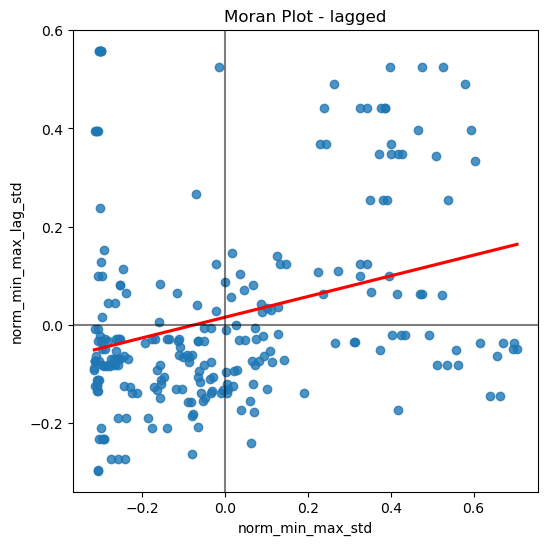

In [20]:
test_subset["norm_min_max_std"] = test_subset["norm_min_max"] - test_subset["norm_min_max"].mean()
test_subset["norm_min_max_lag_std"] = weights.lag_spatial(
    w, test_subset["norm_min_max_std"]
)

f, ax = plt.subplots(1, figsize=(6, 6))
seaborn.regplot(
    x="norm_min_max_std",
    y="norm_min_max_lag_std",
    ci=None,
    data=test_subset,
    line_kws={"color": "r"},
)
ax.axvline(0, c="k", alpha=0.5)
ax.axhline(0, c="k", alpha=0.5)
ax.set_title("Moran Plot - lagged")
plt.show()

Moran's I: 0.21065548765238104, p-value: 0.001


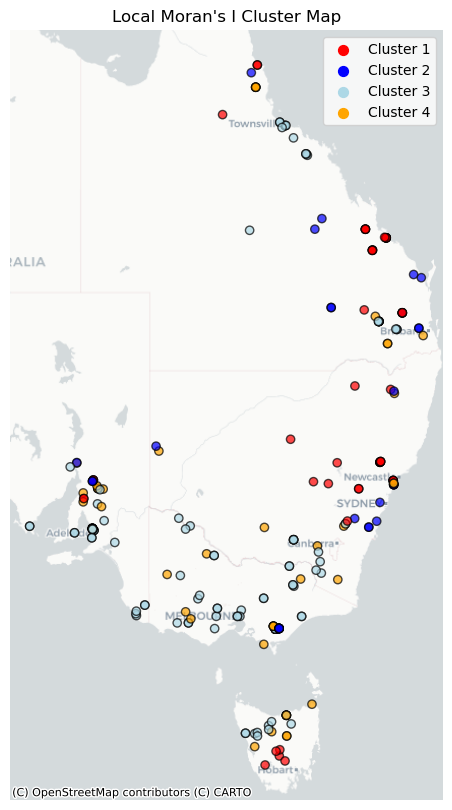

In [53]:
test_subset = test_subset.to_crs(epsg=3857)
y = test_subset['norm_min_max'].values

# Calculate Global Moran's I
mi = Moran(y, w)
print(f"Moran's I: {mi.I}, p-value: {mi.p_sim}")

# Calculate Local Moran's I
m_local = Moran_Local(y, w)

# Assign cluster types (1=HH, 2=LH, 3=LL, 4=HL)
test_subset['cluster'] = m_local.q

# Map cluster values to colors
colors = {
    1: 'red',       # High-High
    2: 'blue',      # Low-High
    3: 'lightblue', # Low-Low
    4: 'orange'     # High-Low
}
test_subset['color'] = test_subset['cluster'].map(colors)

# Plot with basemap
fig, ax = plt.subplots(figsize=(10, 10))
test_subset.plot(ax=ax, color=test_subset['color'], alpha=0.7, edgecolor='k')

# Add basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=5)

# Optional legend
for cluster_id, color in colors.items():
    ax.scatter([], [], c=color, label=f'Cluster {cluster_id}', s=50)
ax.legend()

plt.title("Local Moran's I Cluster Map")
plt.axis('off')
plt.show()

Moran's I: 0.21065548765238104, p-value: 0.001


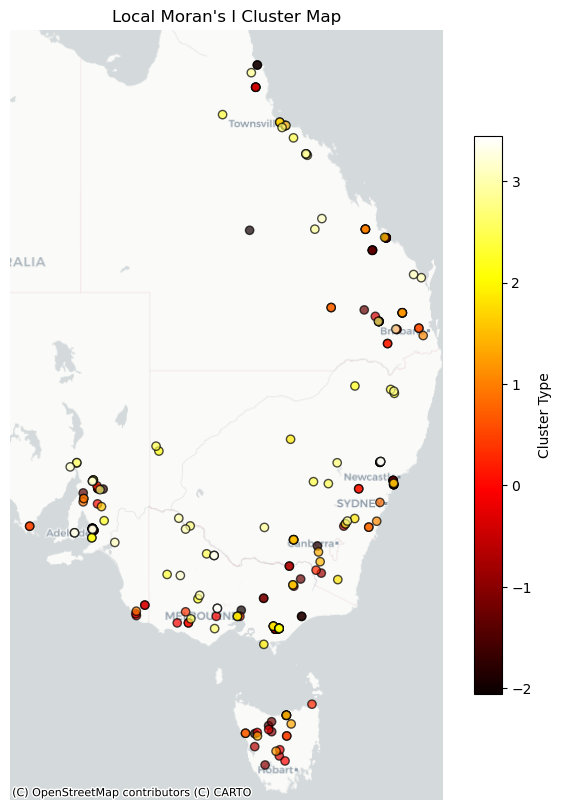

In [66]:
test_subset = test_subset.to_crs(epsg=3857)
y = test_subset['norm_min_max'].values

# Calculate Global Moran's I
mi = Moran(y, w)
print(f"Moran's I: {mi.I}, p-value: {mi.p_sim}")

# Calculate Local Moran's I
m_local = Moran_Local(y, w)

# Assign cluster types (1=HH, 2=LH, 3=LL, 4=HL)
test_subset['cluster'] = m_local.Is

# Plot with basemap
fig, ax = plt.subplots(figsize=(10, 10))
test_subset.plot(ax=ax, c=test_subset['cluster'], cmap='hot', alpha=0.7, edgecolor='k')

# Add basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=5)

cmap = mpl.colormaps['hot']
norm = mpl.colors.Normalize(vmin=test_subset['cluster'].min(), vmax=test_subset['cluster'].max())
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm._A = []  # Dummy array for the ScalarMappable

cbar = fig.colorbar(sm, ax=ax, fraction=0.036, pad=0.04)
cbar.set_label('Local Moran's I Value')

plt.title("Local Moran's I Cluster Map")
plt.axis('off')
plt.show()